<a href="https://colab.research.google.com/github/RutherfordOtu12/Application-of-GeoAI-A-Comparative-Methodical-urban-mapping-/blob/main/WorkFlowA_GPS_Extract.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#!/usr/bin/env python3
"""
WORKFLOW A - STEP 1B: EXTRACT GPS FROM CLASS FOLDERS
Extract GPS coordinates from images organized in 5 class folders
"""

import os
import csv
import json
from PIL import Image
from PIL.ExifTags import TAGS, GPSTAGS
import pandas as pd
import numpy as np
from datetime import datetime
import sys
import zipfile # Import the zipfile module

# 5 Land Use Classes
CLASSES = {
    'Residential_Mixed': 1, # Corrected folder name
    'Commercial_Industrial_LargeScaleReatail_Logistics': 2, # Corrected folder name
    'Public_Institutional': 3,
    'Transport_Infrastructure': 4, # Corrected folder name
    'Others_Unclassified': 5 # Corrected folder name
}

CLASS_NAMES = {
    1: 'Residential/Mixed Use',
    2: 'Commercial/Industrial/L-Scale Retail/Logistics',
    3: 'Public Use/Institutional/Core Area',
    4: 'Transportation and infrastructure',
    5: 'Others/Unclassified'
}

def get_decimal_from_dms(dms, ref):
    """Convert GPS coordinates from DMS to decimal degrees"""
    try:
        degrees = float(dms[0])
        minutes = float(dms[1]) / 60.0
        seconds = float(dms[2]) / 3600.0

        decimal = degrees + minutes + seconds

        if ref in ['S', 'W']:
            decimal = -decimal

        return decimal
    except:
        return None


def extract_gps_from_image(image_path):
    """Extract GPS coordinates from image EXIF metadata"""
    try:
        image = Image.open(image_path)
        exif_data = image._getexif()

        if exif_data is None:
            return None, None

        gps_ifd = None

        for tag, value in exif_data.items():
            if TAGS.get(tag) == "GPSInfo":
                gps_ifd = value
                break

        if gps_ifd is None:
            return None, None

        gps_data = {}
        for tag, value in gps_ifd.items():
            sub_tag = GPSTAGS.get(tag, tag)
            gps_data[sub_tag] = value

        lat_ref = gps_data.get('GPSLatitudeRef', 'N')
        lat_dms = gps_data.get('GPSLatitude')

        lon_ref = gps_data.get('GPSLongitudeRef', 'E')
        lon_dms = gps_data.get('GPSLongitude')

        if lat_dms is None or lon_dms is None:
            return None, None

        latitude = get_decimal_from_dms(lat_dms, lat_ref)
        longitude = get_decimal_from_dms(lon_dms, lon_ref)

        return latitude, longitude

    except Exception as e:
        return None, None


def extract_gps_from_class_folders(organized_folder, output_csv, output_folder=None):
    """
    Extract GPS from images organized in class folders

    Args:
        organized_folder: Path to folder containing 5 class subfolders
        output_csv: Path to save GPS coordinates CSV
        output_folder: Optional path to save reports

    Returns:n        DataFrame with GPS coordinates and class info
    """

    print(f"\n{'='*90}")
    print(f"WORKFLOW A - STEP 1B: EXTRACT GPS FROM CLASS FOLDERS")
    print(f"{'='*90}")
    print(f"📁 Organized folder: {organized_folder}")
    print(f"📄 Output CSV: {output_csv}\n")

    # Create output folder if specified
    if output_folder:
        os.makedirs(output_folder, exist_ok=True)

    # Find all class folders
    print("📂 Scanning for class folders...")
    class_folders = {}

    # Check if organized_folder is a directory
    if not os.path.isdir(organized_folder):
        print(f"❌ ERROR: Organized folder '{organized_folder}' is not a directory.")
        print("Please provide a path to a directory containing the class subfolders.")
        return None

    for class_folder_name in os.listdir(organized_folder):
        class_path = os.path.join(organized_folder, class_folder_name)

        if os.path.isdir(class_path) and class_folder_name in CLASSES:
            class_folders[class_folder_name] = class_path

    if not class_folders:
        print(f"❌ ERROR: No class folders found!")
        print(f"Expected folders: {list(CLASSES.keys())}")
        return None

    print(f"✅ Found {len(class_folders)} class folders: {list(class_folders.keys())}\n")

    # Extract GPS from all images
    print(f"{'='*90}")
    print(f"EXTRACTING GPS FROM CLASS FOLDERS")
    print(f"{'='*90}\n")

    gps_data = []
    total_images = 0
    success_count = 0
    error_count = 0

    for class_folder_name in sorted(class_folders.keys()):
        class_path = class_folders[class_folder_name]
        class_id = CLASSES[class_folder_name]
        class_name = CLASS_NAMES[class_id]

        print(f"\n📂 {class_folder_name}/")
        print(f"   Class ID: {class_id}")
        print(f"   Class Name: {class_name}")
        print(f"   Path: {class_path}\n")

        # Find all image files in this class folder
        image_files = []
        for file in os.listdir(class_path):
            if file.lower().endswith(('.jpg', '.jpeg', '.png', '.heic', '.heif')):
                image_files.append(os.path.join(class_path, file))

        image_files.sort()
        print(f"   Found {len(image_files)} images\n")

        class_success = 0
        class_error = 0

        print(f"   {'Index':<8} {'Status':<5} {'Image Name':<50} {'GPS':<30}")
        print(f"   {'-'*90}")

        for idx, image_path in enumerate(image_files):
            try:
                image_name = os.path.basename(image_path)

                # Extract GPS
                lat, lon = extract_gps_from_image(image_path)

                if lat is not None and lon is not None:
                    gps_data.append({
                        'image_name': image_name,
                        'image_path': image_path,
                        'class_id': class_id,
                        'class_name': class_name,
                        'latitude': lat,
                        'longitude': lon,
                        'status': 'valid'
                    })
                    class_success += 1
                    success_count += 1

                    if (idx + 1) % 50 == 0:
                        print(f"   [{idx+1:5d}] ✅     {image_name:<50} ({lat:.4f}, {lon:.4f})")
                else:
                    gps_data.append({
                        'image_name': image_name,
                        'image_path': image_path,
                        'class_id': class_id,
                        'class_name': class_name,
                        'latitude': None,
                        'longitude': None,
                        'status': 'no_gps'
                    })
                    class_error += 1
                    error_count += 1

                    if (idx + 1) % 50 == 0:
                        print(f"   [{idx+1:5d}] ⚠️      {image_name:<50} NO GPS DATA")

            except Exception as e:
                gps_data.append({
                    'image_name': image_name,
                    'image_path': image_path,
                    'class_id': class_id,
                    'class_name': class_name,
                    'latitude': None,
                    'longitude': None,
                    'status': 'error'
                })
                class_error += 1
                error_count += 1

            total_images += 1

        print(f"\n   ✅ Success: {class_success}/{len(image_files)}")
        print(f"   ❌ Errors:  {class_error}/{len(image_files)}\n")

    print(f"{'='*90}")
    print(f"EXTRACTION SUMMARY")
    print(f"{'='*90}")
    print(f"✅ Successfully extracted: {success_count} images")
    print(f"❌ Errors/No GPS:         {error_count} images")
    print(f"📊 Total GPS points:      {success_count}\n")

    # Create DataFrame
    df = pd.DataFrame(gps_data)

    # Filter valid GPS points
    valid_gps = df[df['status'] == 'valid'].copy()

    if len(valid_gps) == 0:
        print("❌ ERROR: No valid GPS coordinates found!")
        return None

    # Calculate statistics
    print(f"{'='*90}")
    print(f"GPS STATISTICS")
    print(f"{'='*90}\n")

    lats = valid_gps['latitude'].values
    lons = valid_gps['longitude'].values

    print(f"Latitude:  min={lats.min():.4f}°, max={lats.max():.4f}°, mean={lats.mean():.4f}°")
    print(f"Longitude: min={lons.min():.4f}°, max={lons.max():.4f}°, mean={lons.mean():.4f}°")
    print(f"Latitude range:  {lats.max() - lats.min():.4f}°")
    print(f"Longitude range: {lons.max() - lons.min():.4f}°\n")

    # Per-class statistics
    print(f"{'='*90}")
    print(f"PER-CLASS STATISTICS")
    print(f"{'='*90}\n")

    print(f"{'Class':<40} {'Count':<10} {'Percentage':<10}")
    print(f"{'-'*90}")

    for class_id in sorted(CLASSES.values()):
        class_name = CLASS_NAMES[class_id]
        count = len(valid_gps[valid_gps['class_id'] == class_id])
        percentage = 100 * count / len(valid_gps) if len(valid_gps) > 0 else 0
        print(f"{class_name:<40} {count:<10} {percentage:>9.1f}%")

    print()

    # Geographic validation
    print(f"{'='*90}")
    print(f"GEOGRAPHIC VALIDATION (Study Area: Friedrichshain-Kreuzberg, Berlin)")
    print(f"{'='*90}\n")

    # Friedrichshain-Kreuzberg bounds
    fk_lat_min, fk_lat_max = 52.48, 52.52
    fk_lon_min, fk_lon_max = 13.41, 13.47

    # Berlin bounds
    berlin_lat_min, berlin_lat_max = 52.33, 52.68
    berlin_lon_min, berlin_lon_max = 13.08, 13.76

    in_fk = valid_gps[
        (valid_gps['latitude'] >= fk_lat_min) &
        (valid_gps['latitude'] <= fk_lat_max) &
        (valid_gps['longitude'] >= fk_lon_min) &
        (valid_gps['longitude'] <= fk_lon_max)
    ]

    in_berlin = valid_gps[
        (valid_gps['latitude'] >= berlin_lat_min) &
        (valid_gps['latitude'] <= berlin_lat_max) &
        (valid_gps['longitude'] >= berlin_lon_min) &
        (valid_gps['longitude'] <= berlin_lon_max)
    ]

    print(f"✅ Points in FK district:  {len(in_fk)}/{len(valid_gps)} ({100*len(in_fk)/len(valid_gps):.1f}%)")
    print(f"✅ Points in Berlin:       {len(in_berlin)}/{len(valid_gps)} ({100*len(in_berlin)/len(valid_gps):.1f}%)\n")

    # Save GPS coordinates
    print(f"{'='*90}")
    print(f"SAVING RESULTS")
    print(f"{'='*90}\n")

    # Save only valid GPS points
    output_df = valid_gps[['image_name', 'image_path', 'class_id', 'class_name', 'latitude', 'longitude']].copy()
    output_df.to_csv(output_csv, index=False)

    print(f"✅ GPS coordinates saved: {output_csv}")
    print(f"   Total points: {len(output_df)}\n")

    # Save detailed report
    if output_folder:
        report = {
            'timestamp': datetime.now().isoformat(),
            'study_area': 'Friedrichshain-Kreuzberg, Berlin',
            'total_images': total_images,
            'images_with_gps': success_count,
            'images_without_gps': error_count,
            'valid_gps_points': len(valid_gps),
            'points_in_fk_district': len(in_fk),
            'points_in_berlin': len(in_berlin),
            'coordinate_ranges': {
                'latitude': {'min': float(lats.min()), 'max': float(lats.max()), 'mean': float(lats.mean())},
                'longitude': {'min': float(lons.min()), 'max': float(lons.max()), 'mean': float(lons.mean())}
            },
            'class_distribution': {}
        }

        for class_id in sorted(CLASSES.values()):
            class_name = CLASS_NAMES[class_id]
            count = len(valid_gps[valid_gps['class_id'] == class_id])
            report['class_distribution'][class_name] = count

        report_path = os.path.join(output_folder, 'gps_extraction_report.json')
        with open(report_path, 'w') as f:
            json.dump(report, f, indent=2)

        print(f"✅ Report saved: {report_path}\n")

    # Display sample GPS points
    print(f"{'='*90}")
    print(f"SAMPLE GPS POINTS")
    print(f"{'='*90}\n")

    print(f"{'Class':<30} {'Image Name':<40} {'Latitude':<12} {'Longitude':<12}")
    print(f"{'-'*90}")

    for idx, row in valid_gps.head(10).iterrows():
        class_name = row['class_name'].split('/')[0]  # First part of class name
        print(f"{class_name:<30} {row['image_name']:<40} {row['latitude']:<12.4f} {row['longitude']:<12.4f}")

    if len(valid_gps) > 10:
        print(f"... and {len(valid_gps) - 10} more points")

    print(f"\n{'='*90}\n")

    return output_df


def verify_output_csv(output_csv):
    """Verify the output CSV file"""

    print(f"{'='*90}")
    print(f"VERIFICATION: Checking output CSV")
    print(f"{'='*90}\n")

    try:
        df = pd.read_csv(output_csv)

        print(f"✅ CSV file readable")
        print(f"✅ Total GPS points: {len(df)}")
        print(f"✅ Columns: {list(df.columns)}")
        print(f"✅ All coordinates valid: {df['latitude'].notna().all() and df['longitude'].notna().all()}\n")

        return True

    except Exception as e:
        print(f"❌ ERROR: {str(e)}\n")
        return False


def main():
    """Main function"""

    # ===== CONFIGURATION =====
    # Update these paths to your actual locations

    ZIP_FILE_PATH = "/content/drive/MyDrive/SLI.zip"
    EXTRACT_FOLDER = "/content/SLI_extracted"

    # Unzip the file if it exists and hasn't been unzipped already
    if os.path.exists(ZIP_FILE_PATH) and not os.path.exists(EXTRACT_FOLDER):
        print(f"Unzipping {ZIP_FILE_PATH} to {EXTRACT_FOLDER}...")
        with zipfile.ZipFile(ZIP_FILE_PATH, 'r') as zip_ref:
            zip_ref.extractall(EXTRACT_FOLDER)
        print("Unzipping complete.")
    elif os.path.exists(EXTRACT_FOLDER):
        print(f"Directory {EXTRACT_FOLDER} already exists. Skipping unzipping.")
    else:
        print(f"Error: ZIP file not found at {ZIP_FILE_PATH}")
        sys.exit(1)

    # Add a command to list the contents of the extracted folder to help find the correct image path
    print(f"\nListing contents of {EXTRACT_FOLDER}:")
    !ls -R "{EXTRACT_FOLDER}"
    print("\n")

    ORGANIZED_FOLDER = os.path.join(EXTRACT_FOLDER, 'SLI')  # Folder with 5 class subfolders
    OUTPUT_CSV = "/content/drive/MyDrive/Workflow A/gps_with_classes.csv"    # Output CSV file
    OUTPUT_FOLDER = "/content/drive/MyDrive/Workflow A"    # Output folder for reports

    # ===== END CONFIGURATION =====

    # Extract GPS from class folders
    df = extract_gps_from_class_folders(ORGANIZED_FOLDER, OUTPUT_CSV, OUTPUT_FOLDER)

    if df is not None:
        # Verify output
        if verify_output_csv(OUTPUT_CSV):
            print("✅ SUCCESS: GPS extraction complete!")
            print(f"\nNext step: Run workflow_a_03_preprocess_images.py")
            print(f"This will resize images to 224\u00d7224 and prepare for training\n")
            return 0
        else:
            print("⚠️  WARNING: GPS extraction completed but verification failed")
            return 1
    else:
        print("❌ ERROR: GPS extraction failed")
        return 2


if __name__ == "__main__":
    exit_code = main()
    sys.exit(exit_code)

Directory /content/SLI_extracted already exists. Skipping unzipping.

Listing contents of /content/SLI_extracted:
/content/SLI_extracted:
__MACOSX  SLI

/content/SLI_extracted/__MACOSX:
SLI

/content/SLI_extracted/__MACOSX/SLI:
Commercial_Industrial_LargeScaleReatail_Logistics  Residential_Mixed
Others_Unclassified				   Transport_Infrastructure
Public_Institutional

/content/SLI_extracted/__MACOSX/SLI/Commercial_Industrial_LargeScaleReatail_Logistics:

/content/SLI_extracted/__MACOSX/SLI/Others_Unclassified:

/content/SLI_extracted/__MACOSX/SLI/Public_Institutional:

/content/SLI_extracted/__MACOSX/SLI/Residential_Mixed:

/content/SLI_extracted/__MACOSX/SLI/Transport_Infrastructure:

/content/SLI_extracted/SLI:
Commercial_Industrial_LargeScaleReatail_Logistics  Residential_Mixed
Others_Unclassified				   Transport_Infrastructure
Public_Institutional

/content/SLI_extracted/SLI/Commercial_Industrial_LargeScaleReatail_Logistics:
'IMG_0620 2.JPG'   IMG_0958.JPG      IMG_1253.JPG   IMG_16

SystemExit: 0

/usr/local/lib/python3.12/dist-packages/IPython/core/interactiveshell.py:3561: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)


In [4]:

"""
Load study area boundary from QGIS shapefile
"""

import geopandas as gpd
import os

# Define path to shapefile
shapefile_path = '/content/drive/MyDrive/WorkflowB/Study Area Boundary/Study Area Boundary.shp'

# Verify file exists
if not os.path.exists(shapefile_path):
    print(f"ERROR: Shapefile not found at: {shapefile_path}")
    print("\nMake sure you uploaded:")
    print("  - Study Area Boundary.shp")
    print("  - Study Area Boundary.shx")
    print("  - Study Area Boundary.dbf")
    print("  - Study Area Boundary.prj")
else:
    # Load shapefile
    study_area = gpd.read_file(shapefile_path)

    if study_area.empty:
        print(f"ERROR: The shapefile at {shapefile_path} was loaded, but it contains no features (it's empty).")
        print("Please ensure your shapefile contains at least one valid geometry.")
    else:
        print(f"✓ Loaded shapefile!")
        print(f"  Number of features: {len(study_area)}")
        print(f"  CRS: {study_area.crs}")
        print(f"  Geometry type: {study_area.geometry.type.unique()}")
        print(f"\nBounds:")
        print(f"  Min X: {study_area.bounds.minx.values[0]:.4f}")
        print(f"  Min Y: {study_area.bounds.miny.values[0]:.4f}")
        print(f"  Max X: {study_area.bounds.maxx.values[0]:.4f}")
        print(f"  Max Y: {study_area.bounds.maxy.values[0]:.4f}")

        # Get geometry
        geometry = study_area.geometry[0]
        print(f"\nGeometry area: {geometry.area:.6f} degrees²")


✓ Loaded shapefile!
  Number of features: 1
  CRS: EPSG:4326
  Geometry type: ['Polygon']

Bounds:
  Min X: 13.3682
  Min Y: 52.4828
  Max X: 13.4914
  Max Y: 52.5310

Geometry area: 0.002695 degrees²


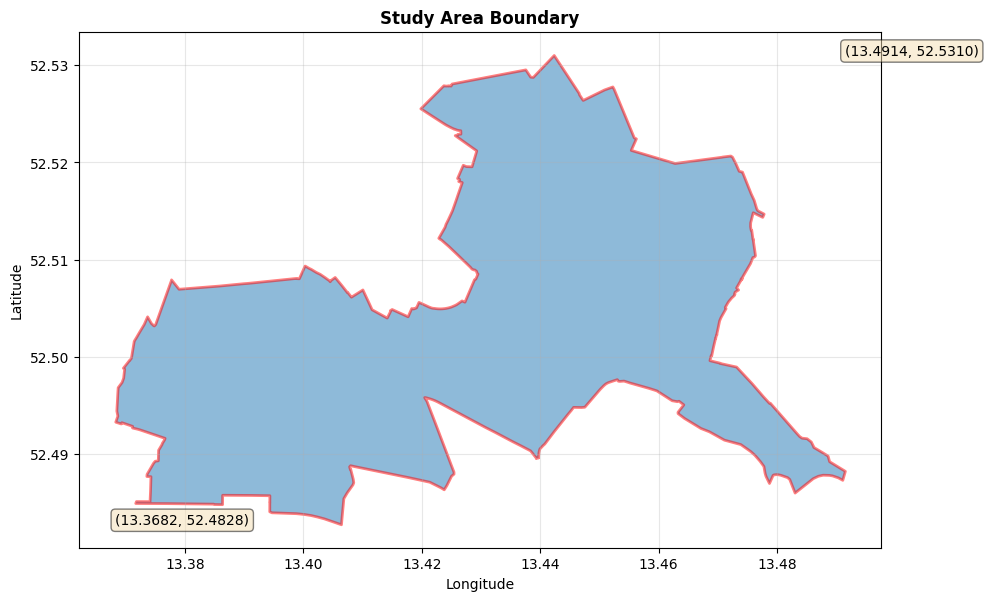

✓ Shapefile boundary visualized!


In [5]:
"""
Visualize shapefile boundary
"""

import matplotlib.pyplot as plt

# Create figure
fig, ax = plt.subplots(figsize=(10, 8))

# Plot shapefile
study_area.plot(ax=ax, alpha=0.5, edgecolor='red', linewidth=2)

# Add labels
ax.set_title('Study Area Boundary', fontsize=12, fontweight='bold')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.grid(True, alpha=0.3)

# Add coordinates
bounds = study_area.bounds.iloc[0]
ax.text(bounds.minx, bounds.miny, f"({bounds.minx:.4f}, {bounds.miny:.4f})",
        fontsize=10, bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
ax.text(bounds.maxx, bounds.maxy, f"({bounds.maxx:.4f}, {bounds.maxy:.4f})",
        fontsize=10, bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()

print("✓ Shapefile boundary visualized!")

In [ ]:
#!/usr/bin/env python3
"""
WORKFLOW A - STEP 2: BLUR FACES AND LICENSE PLATES
GDPR compliance: Anonymize people and vehicle information
"""

import os
import cv2
import numpy as np
from datetime import datetime
import json
import sys

def blur_faces(image, face_cascade):
    """Detect and blur faces in image"""
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    faces = face_cascade.detectMultiScale(gray, scaleFactor=1.1, minNeighbors=5, minSize=(30, 30))

    blurred_count = 0
    for (x, y, w, h) in faces:
        # Blur the face region
        roi = image[y:y+h, x:x+w]
        blurred_roi = cv2.GaussianBlur(roi, (99, 99), 0)
        image[y:y+h, x:x+w] = blurred_roi
        blurred_count += 1

    return image, blurred_count


def blur_license_plates(image, plate_cascade):
    """Detect and blur license plates in image"""
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    plates = plate_cascade.detectMultiScale(gray, scaleFactor=1.1, minNeighbors=5, minSize=(30, 15))

    blurred_count = 0
    for (x, y, w, h) in plates:
        # Blur the plate region
        roi = image[y:y+h, x:x+w]
        blurred_roi = cv2.GaussianBlur(roi, (99, 99), 0)
        image[y:y+h, x:x+w] = blurred_roi
        blurred_count += 1

    return image, blurred_count


def process_image(image_path, output_path, face_cascade, plate_cascade):
    """Process single image: detect and blur faces/plates"""
    try:
        # Read image
        image = cv2.imread(image_path)
        if image is None:
            return False, 0, 0, "Could not read image"

        # Blur faces
        image, face_count = blur_faces(image, face_cascade)

        # Blur license plates
        image, plate_count = blur_license_plates(image, plate_cascade)

        # Save blurred image
        os.makedirs(os.path.dirname(output_path), exist_ok=True)
        cv2.imwrite(output_path, image)

        return True, face_count, plate_count, None

    except Exception as e:
        return False, 0, 0, str(e)


def blur_organized_images(organized_folder, output_folder):
    """
    Blur faces and license plates in all organized images

    Args:
        organized_folder: Path to folder with 5 class subfolders
        output_folder: Path to save blurred images

    Returns:
        Dictionary with processing results
    """

    print(f"\n{'='*90}")
    print(f"WORKFLOW A - STEP 2: BLUR FACES AND LICENSE PLATES")
    print(f"{'='*90}")
    print(f"📁 Input folder: {organized_folder}")
    print(f"📁 Output folder: {output_folder}\n")

    # Load cascade classifiers
    print("📚 Loading detection models...")

    face_cascade_path = cv2.data.haarcascades + 'haarcascade_frontalface_default.xml'
    plate_cascade_path = cv2.data.haarcascades + 'haarcascade_russian_plate_number.xml'

    face_cascade = cv2.CascadeClassifier(face_cascade_path)
    plate_cascade = cv2.CascadeClassifier(plate_cascade_path)

    if face_cascade.empty():
        print("❌ ERROR: Could not load face detection model")
        return None

    print(f"✅ Face detection model loaded")
    print(f"✅ License plate detection model loaded\n")

    # Find all class folders
    print("📂 Scanning for class folders...")
    class_folders = {}

    for class_folder_name in os.listdir(organized_folder):
        class_path = os.path.join(organized_folder, class_folder_name)
        if os.path.isdir(class_path):
            class_folders[class_folder_name] = class_path

    if not class_folders:
        print(f"❌ ERROR: No class folders found!")
        return None

    print(f"✅ Found {len(class_folders)} class folders\n")

    # Process all images
    print(f"{'='*90}")
    print(f"PROCESSING IMAGES")
    print(f"{'='*90}\n")

    results = {
        'timestamp': datetime.now().isoformat(),
        'total_images': 0,
        'successfully_processed': 0,
        'errors': 0,
        'total_faces_blurred': 0,
        'total_plates_blurred': 0,
        'class_statistics': {}
    }

    for class_folder_name in sorted(class_folders.keys()):
        class_input_path = class_folders[class_folder_name]
        class_output_path = os.path.join(output_folder, class_folder_name)

        print(f"📂 {class_folder_name}/")

        # Find all image files
        image_files = []
        for file in os.listdir(class_input_path):
            if file.lower().endswith(('.jpg', '.jpeg', '.png', '.heic', '.heif')):
                image_files.append(file)

        image_files.sort()
        print(f"   Found {len(image_files)} images\n")

        class_success = 0
        class_faces = 0
        class_plates = 0
        class_errors = 0

        print(f"   {'Index':<8} {'Status':<5} {'Image':<40} {'Faces':<8} {'Plates':<8}")
        print(f"   {'-'*90}")

        for idx, image_name in enumerate(image_files):
            image_input_path = os.path.join(class_input_path, image_name)
            image_output_path = os.path.join(class_output_path, image_name)

            success, face_count, plate_count, error = process_image(
                image_input_path, image_output_path, face_cascade, plate_cascade
            )

            if success:
                class_success += 1
                class_faces += face_count
                class_plates += plate_count
                results['successfully_processed'] += 1
                results['total_faces_blurred'] += face_count
                results['total_plates_blurred'] += plate_count

                if (idx + 1) % 50 == 0:
                    print(f"   [{idx+1:5d}] ✅     {image_name:<40} {face_count:<8} {plate_count:<8}")
            else:
                class_errors += 1
                results['errors'] += 1
                if (idx + 1) % 50 == 0:
                    print(f"   [{idx+1:5d}] ❌     {image_name:<40} ERROR")

            results['total_images'] += 1

        print(f"\n   ✅ Processed: {class_success}/{len(image_files)}")
        print(f"   👤 Faces blurred: {class_faces}")
        print(f"   🚗 Plates blurred: {class_plates}")
        print(f"   ❌ Errors: {class_errors}\n")

        results['class_statistics'][class_folder_name] = {
            'total_images': len(image_files),
            'successfully_processed': class_success,
            'faces_blurred': class_faces,
            'plates_blurred': class_plates,
            'errors': class_errors
        }

    print(f"{'='*90}")
    print(f"PROCESSING SUMMARY")
    print(f"{'='*90}")
    print(f"✅ Total images: {results['total_images']}")
    print(f"✅ Successfully processed: {results['successfully_processed']}")
    print(f"❌ Errors: {results['errors']}")
    print(f"👤 Total faces blurred: {results['total_faces_blurred']}")
    print(f"🚗 Total license plates blurred: {results['total_plates_blurred']}\n")

    return results


def save_results(results, output_folder):
    """Save processing results to JSON"""

    report_path = os.path.join(output_folder, 'blurring_report.json')

    with open(report_path, 'w') as f:
        json.dump(results, f, indent=2)

    print(f"✅ Report saved: {report_path}\n")


def main():
    """Main function"""

    # ===== CONFIGURATION =====
    # Update these paths to your actual locations

    ORGANIZED_FOLDER = "/content/SLI_extracted/SLI"  # Input: 5 class folders
    OUTPUT_FOLDER = "/content/drive/MyDrive/Workflow A/blurred_images"       # Output: Blurred images

    # ===== END CONFIGURATION =====

    # Process images
    results = blur_organized_images(ORGANIZED_FOLDER, OUTPUT_FOLDER)

    if results:
        # Save results
        save_results(results, OUTPUT_FOLDER)

        print("✅ SUCCESS: Face and license plate blurring complete!")
        print(f"\nGDPR Compliance:")
        print(f"  ✅ {results['total_faces_blurred']} faces blurred")
        print(f"  ✅ {results['total_plates_blurred']} license plates blurred")
        print(f"\nNext step: Run workflow_a_03_preprocess_images.py")
        print(f"This will resize images to 224\u00d7224 and prepare for training\n")

        return 0
    else:
        print("❌ ERROR: Blurring failed")
        return 1


if __name__ == "__main__":
    exit_code = main()
    sys.exit(exit_code)


WORKFLOW A - STEP 2: BLUR FACES AND LICENSE PLATES
📁 Input folder: /content/SLI_extracted/SLI
📁 Output folder: /content/drive/MyDrive/Workflow A/blurred_images

📚 Loading detection models...
✅ Face detection model loaded
✅ License plate detection model loaded

📂 Scanning for class folders...
✅ Found 5 class folders

PROCESSING IMAGES

📂 Commercial_Industrial_LargeScaleReatail_Logistics/
   Found 381 images

   Index    Status Image                                    Faces    Plates  
   ------------------------------------------------------------------------------------------
   [   50] ✅     IMG_0744 2.JPG                           3        0       
   [  100] ✅     IMG_0967.JPG                             4        1       
   [  150] ✅     IMG_1183.JPG                             2        0       
   [  200] ✅     IMG_1322.JPG                             7        2       
   [  250] ✅     IMG_1452.JPG                             10       2       
   [  300] ✅     IMG_1647.JPG       

SystemExit: 0

/usr/local/lib/python3.12/dist-packages/IPython/core/interactiveshell.py:3561: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)


## Sample Blurred Images

Displaying one sample blurred image from each class:



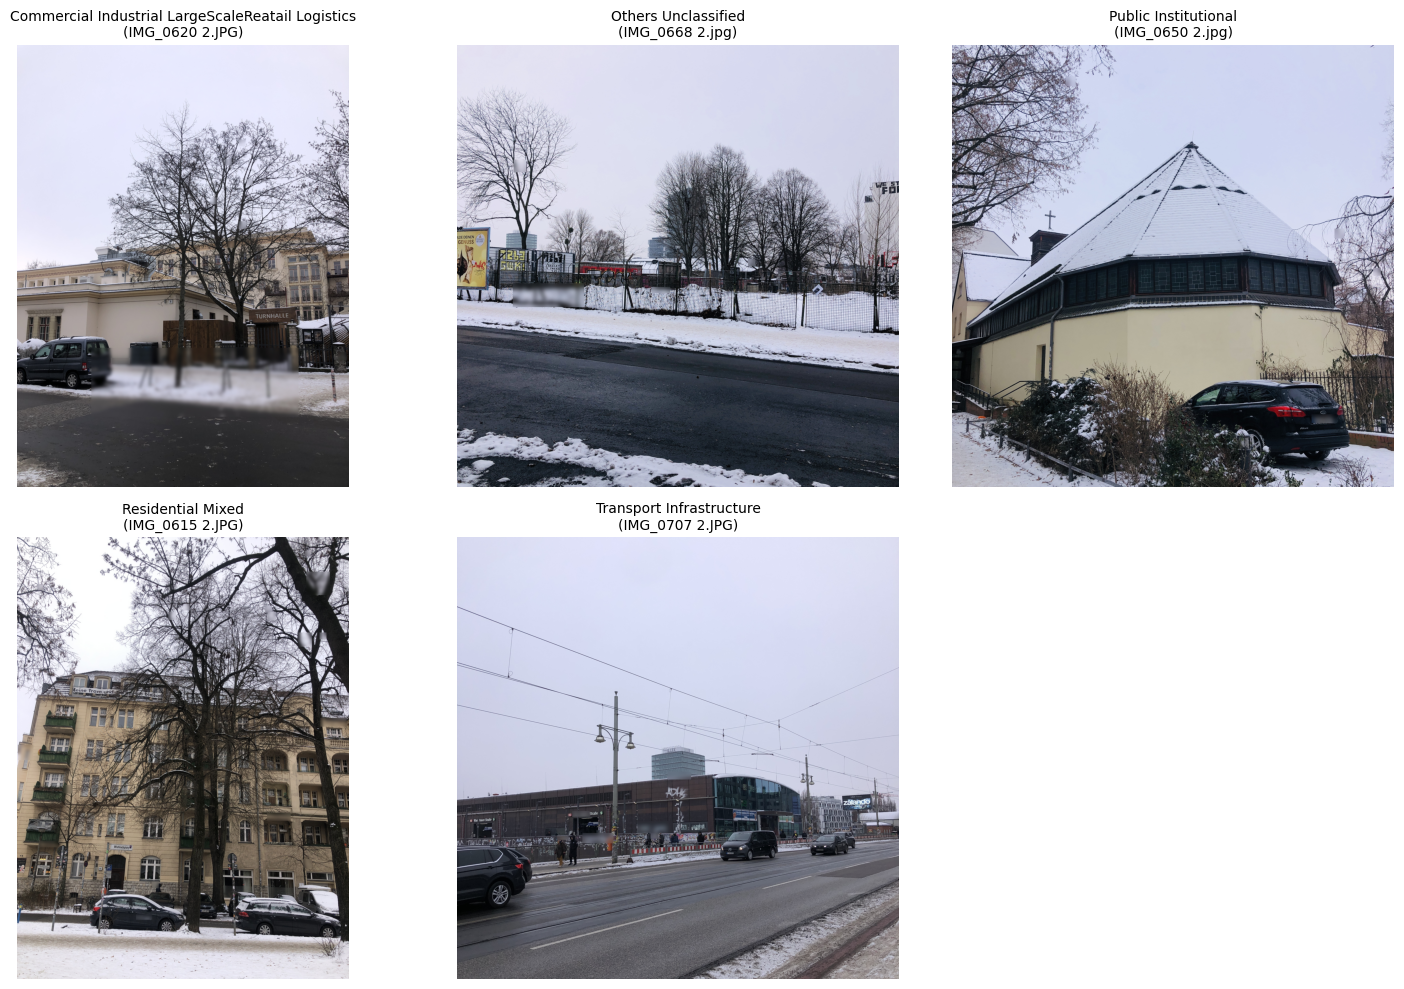

In [6]:
import matplotlib.pyplot as plt
import cv2
import os

# Define the input and output folders used in the blurring step
ORGANIZED_FOLDER = "/content/SLI_extracted/SLI"
OUTPUT_FOLDER = "/content/drive/MyDrive/Workflow A/blurred_images"

# 5 Land Use Classes (from previous cell)
CLASSES = {
    'Residential_Mixed': 1,
    'Commercial_Industrial_LargeScaleReatail_Logistics': 2,
    'Public_Institutional': 3,
    'Transport_Infrastructure': 4,
    'Others_Unclassified': 5
}

print("Displaying one sample blurred image from each class:\n")

plt.figure(figsize=(15, 10))

for i, class_folder_name in enumerate(sorted(CLASSES.keys())):
    class_output_path = os.path.join(OUTPUT_FOLDER, class_folder_name)

    if not os.path.exists(class_output_path):
        print(f"❌ Blurred images folder for '{class_folder_name}' not found: {class_output_path}")
        continue

    # Get a list of blurred image files in the current class folder
    blurred_image_files = [f for f in os.listdir(class_output_path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]

    if not blurred_image_files:
        print(f"⚠️  No blurred images found in '{class_folder_name}'")
        continue

    # Pick the first image to display
    sample_image_name = blurred_image_files[0]
    sample_image_path = os.path.join(class_output_path, sample_image_name)

    try:
        img = cv2.imread(sample_image_path)
        if img is None:
            print(f"❌ Could not read image: {sample_image_path}")
            continue

        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        plt.subplot(2, 3, i + 1) # Create subplots (adjust layout as needed)
        plt.imshow(img_rgb)
        plt.title(f"{class_folder_name.replace('_', ' ')}\n({sample_image_name})", fontsize=10)
        plt.axis('off')

    except Exception as e:
        print(f"❌ Error displaying image {sample_image_name}: {e}")

plt.tight_layout()
plt.show()
